# Microbiological Techniques — Serial Dilution, Spread & Pour Plate

**Objective:** Calculate colony-forming units per mL (CFU/mL) from serial
dilution plate counts, using only plates within the statistically countable
range (30-300 colonies).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/plate_counts.csv")
df

,dilution_exponent,volume_ml,colonies
0,-2,0.1,TNTC
1,-3,0.1,212
2,-4,0.1,34
3,-5,0.1,4


## Flag countable plates and calculate CFU/mL

In [2]:
COUNTABLE_MIN, COUNTABLE_MAX = 30, 300

def is_countable(val):
    return val.isdigit() and COUNTABLE_MIN <= int(val) <= COUNTABLE_MAX

df["countable"] = df.colonies.apply(is_countable)

def cfu_per_ml(row):
    if not row.countable:
        return None
    dilution_factor = 10 ** row.dilution_exponent
    return (int(row.colonies) / row.volume_ml) / dilution_factor

df["cfu_per_ml"] = df.apply(cfu_per_ml, axis=1)
df

,dilution_exponent,volume_ml,colonies,countable,cfu_per_ml
0,-2,0.1,TNTC,False,NaN
1,-3,0.1,212,True,2120000.0
2,-4,0.1,34,True,3400000.0
3,-5,0.1,4,False,NaN


## Average CFU/mL across countable plates

In [3]:
valid = df.dropna(subset=["cfu_per_ml"])
avg_cfu = valid.cfu_per_ml.mean()
print(f"Average CFU/mL (from countable plates): {avg_cfu:.2e}")

Average CFU/mL (from countable plates): 2.76e+06


## Visualise CFU/mL estimates by dilution

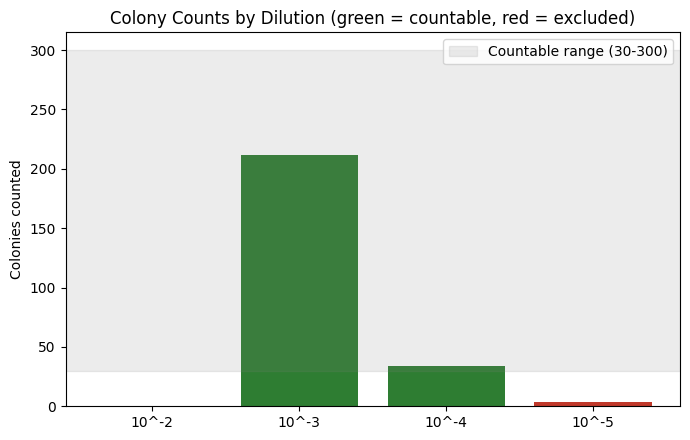

In [4]:
plt.figure(figsize=(7, 4.5))
labels = [f"10^{e}" for e in df.dilution_exponent]
colors = ["#2E7D32" if c else "#C0392B" for c in df.countable]
plt.bar(labels, df.colonies.apply(lambda v: int(v) if v.isdigit() else 0), color=colors)
plt.axhspan(COUNTABLE_MIN, COUNTABLE_MAX, color="grey", alpha=0.15, label="Countable range (30-300)")
plt.ylabel("Colonies counted")
plt.title("Colony Counts by Dilution (green = countable, red = excluded)")
plt.legend()
plt.tight_layout()
plt.savefig("dilution_plate_counts.png", dpi=150)
plt.show()

## Summary

Only dilutions producing colony counts within the countable range
(30-300) were used for CFU/mL calculation. Plates outside this range
(too numerous to count, or too few colonies for statistical reliability)
were excluded, and the final CFU/mL estimate is the average across the
remaining valid dilutions.
